# Base Imports

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("/kaggle/input/datasets/zafarali27/house-price-prediction-dataset/House Price Prediction Dataset.csv")

In [3]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [4]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [5]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [7]:
df.drop(columns = 'Id',inplace = True)

In [8]:
df.drop(columns = 'YearBuilt',inplace = True)

In [9]:
for col in df:
    print(col , " has ", df[col].nunique() , " values.")

Area  has  1622  values.
Bedrooms  has  5  values.
Bathrooms  has  4  values.
Floors  has  3  values.
Location  has  4  values.
Condition  has  4  values.
Garage  has  2  values.
Price  has  1999  values.


In [10]:
print("categorical values are ", df.select_dtypes(include = 'object').columns)
print("numerical values are ", df.select_dtypes(include = 'int64').columns)

categorical values are  Index(['Location', 'Condition', 'Garage'], dtype='object')
numerical values are  Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Price'], dtype='object')


# Visualizations

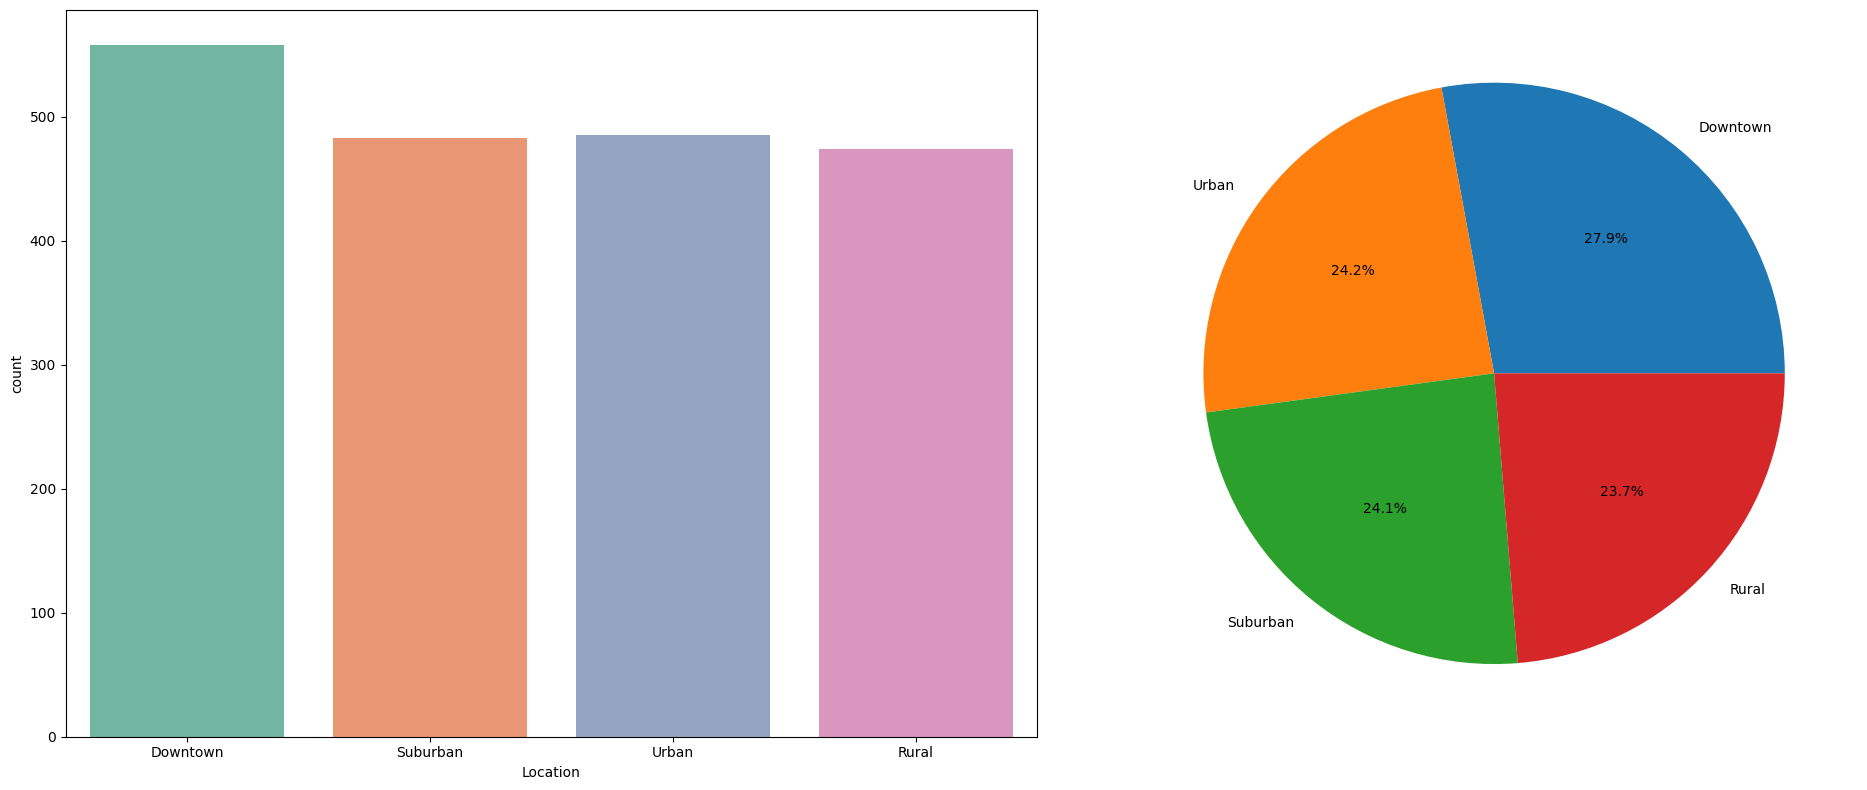

Unique vales 4
Missing values in Location 0


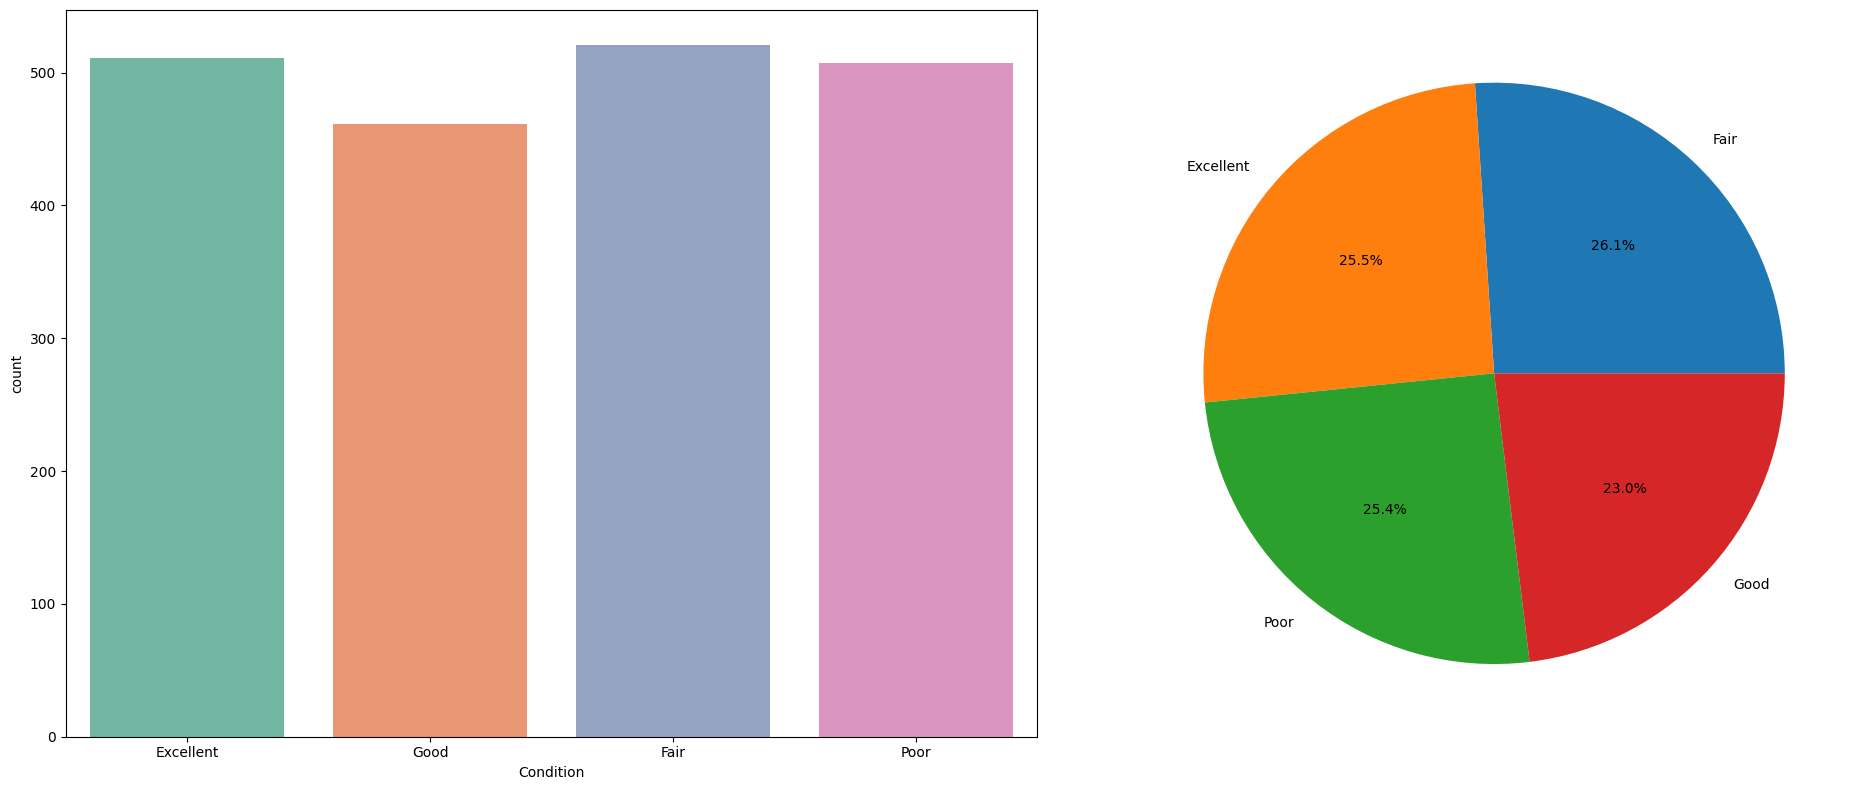

Unique vales 4
Missing values in Condition 0


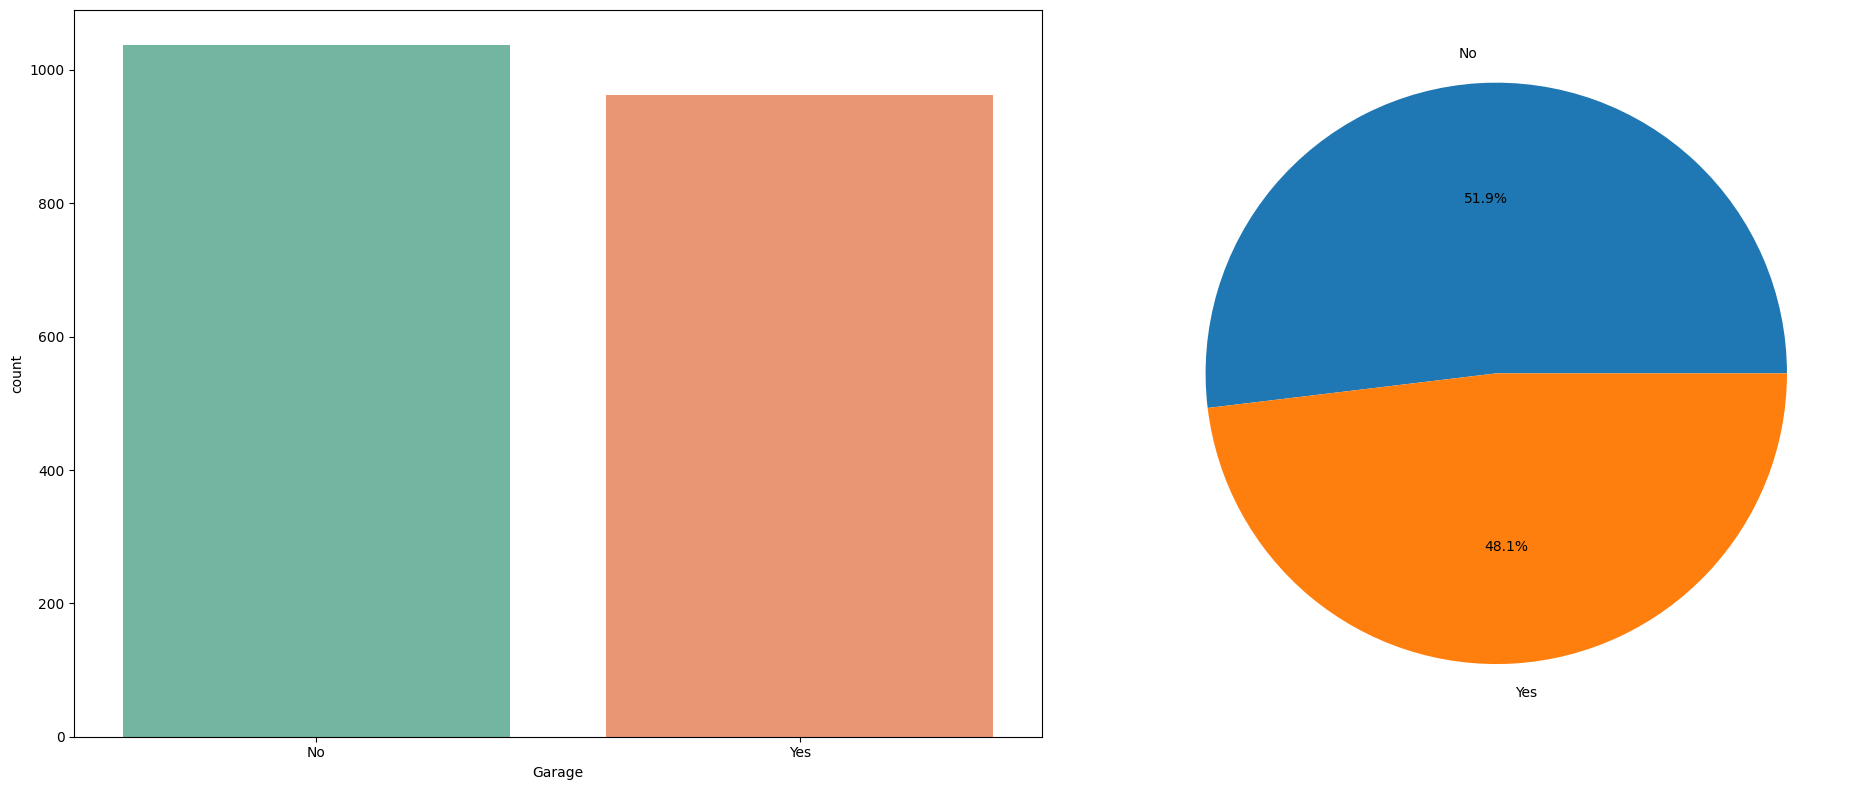

Unique vales 2
Missing values in Garage 0


In [11]:
categoric  =  ['Location', 'Condition', 'Garage']
for category in categoric : 
    plt.figure(figsize = (20,8))
    counts = df[category].value_counts()
    plt.subplot(1,2,1)
    sns.countplot(x = category , data = df ,palette = "Set2",hue = category , legend = False)
    plt.subplot(1,2,2)
    plt.pie(counts , labels = counts.index , data = df, autopct= "%1.1f%%")
    plt.tight_layout()
    plt.show()
    print("Unique vales" , df[category].nunique())
    print(f"Missing values in {category}" , df[category].isna().sum())

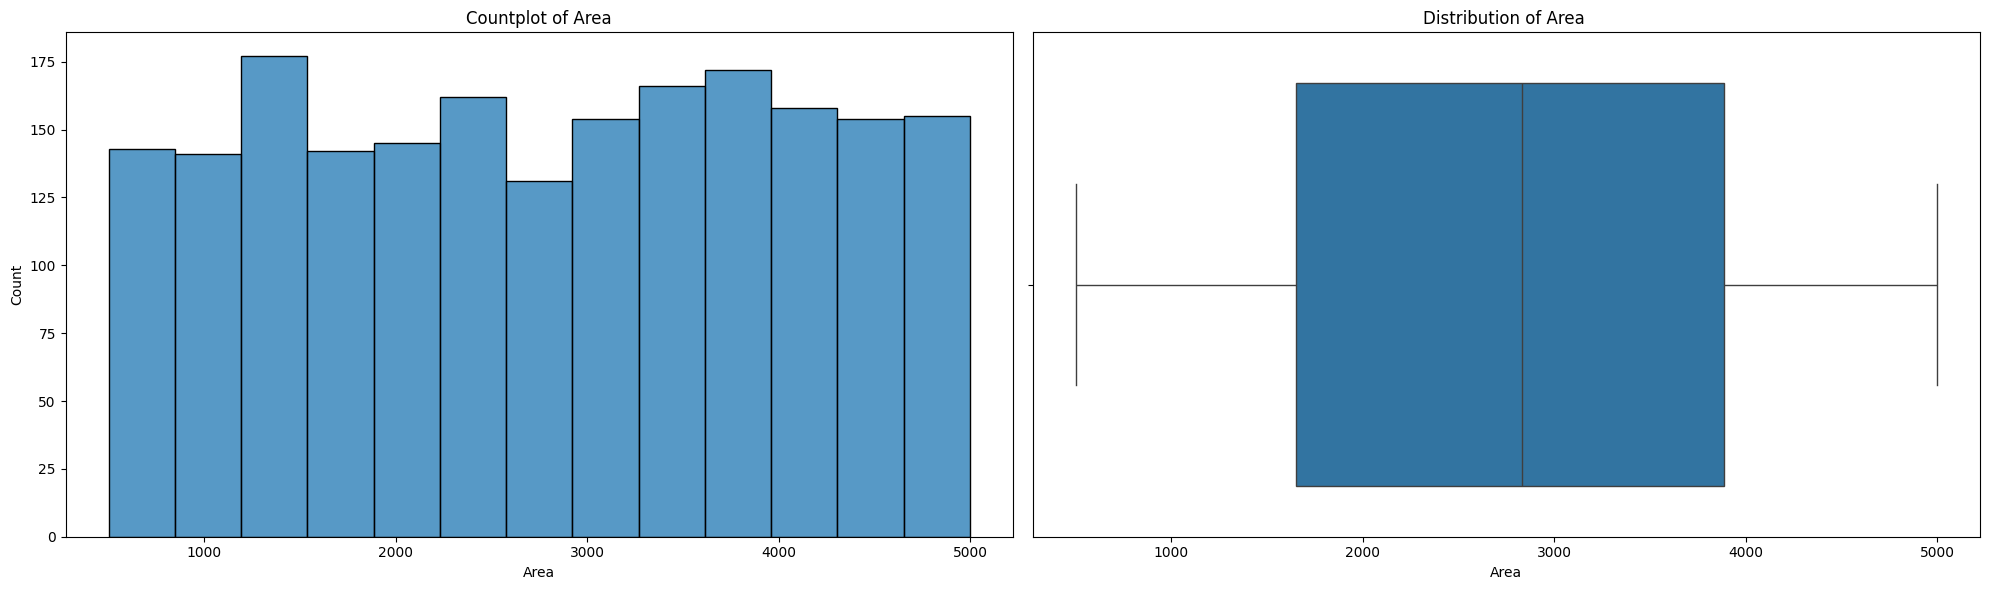

Unique vales 1622
Missing values in Area 0


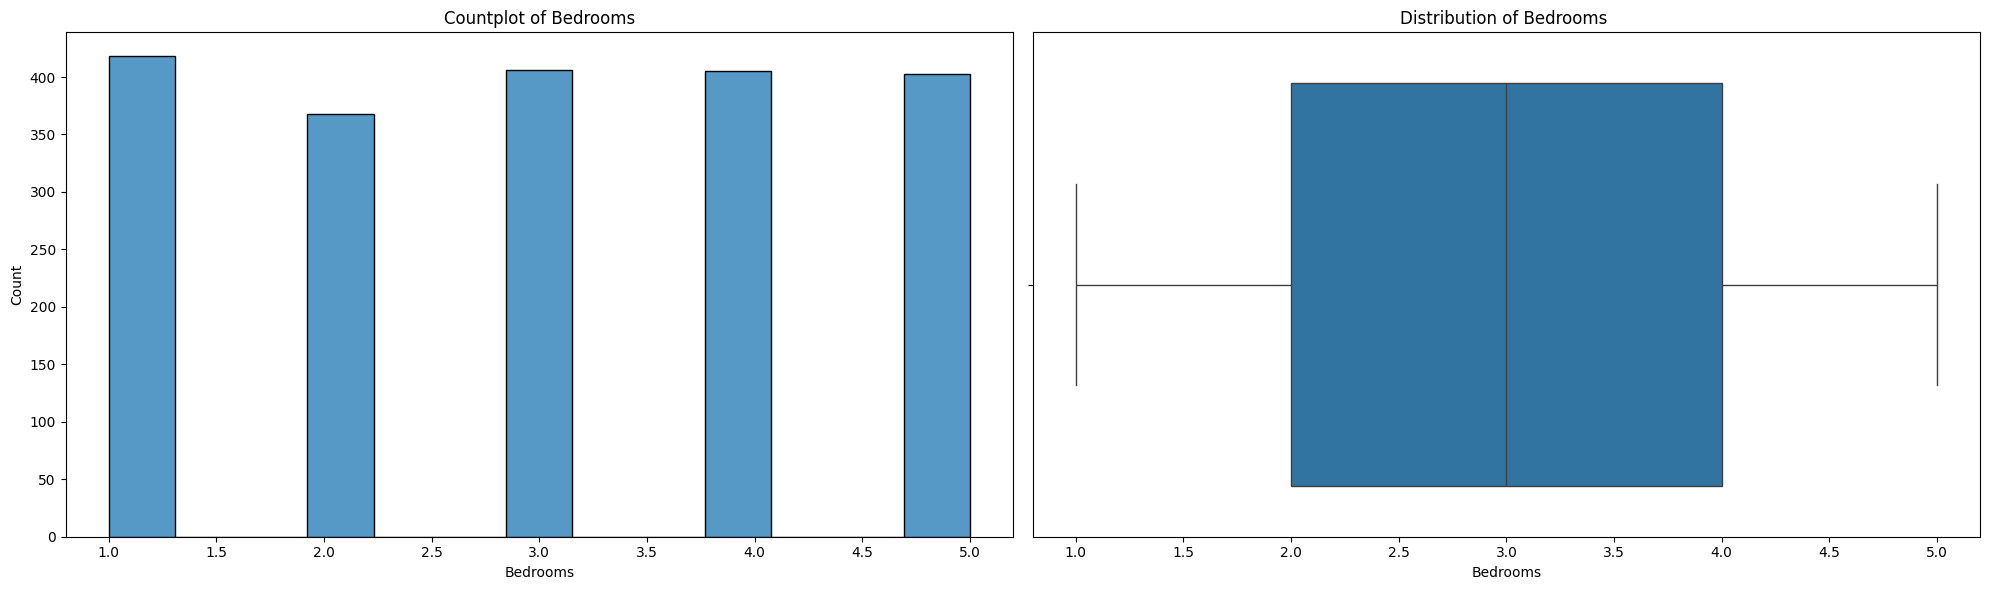

Unique vales 5
Missing values in Bedrooms 0


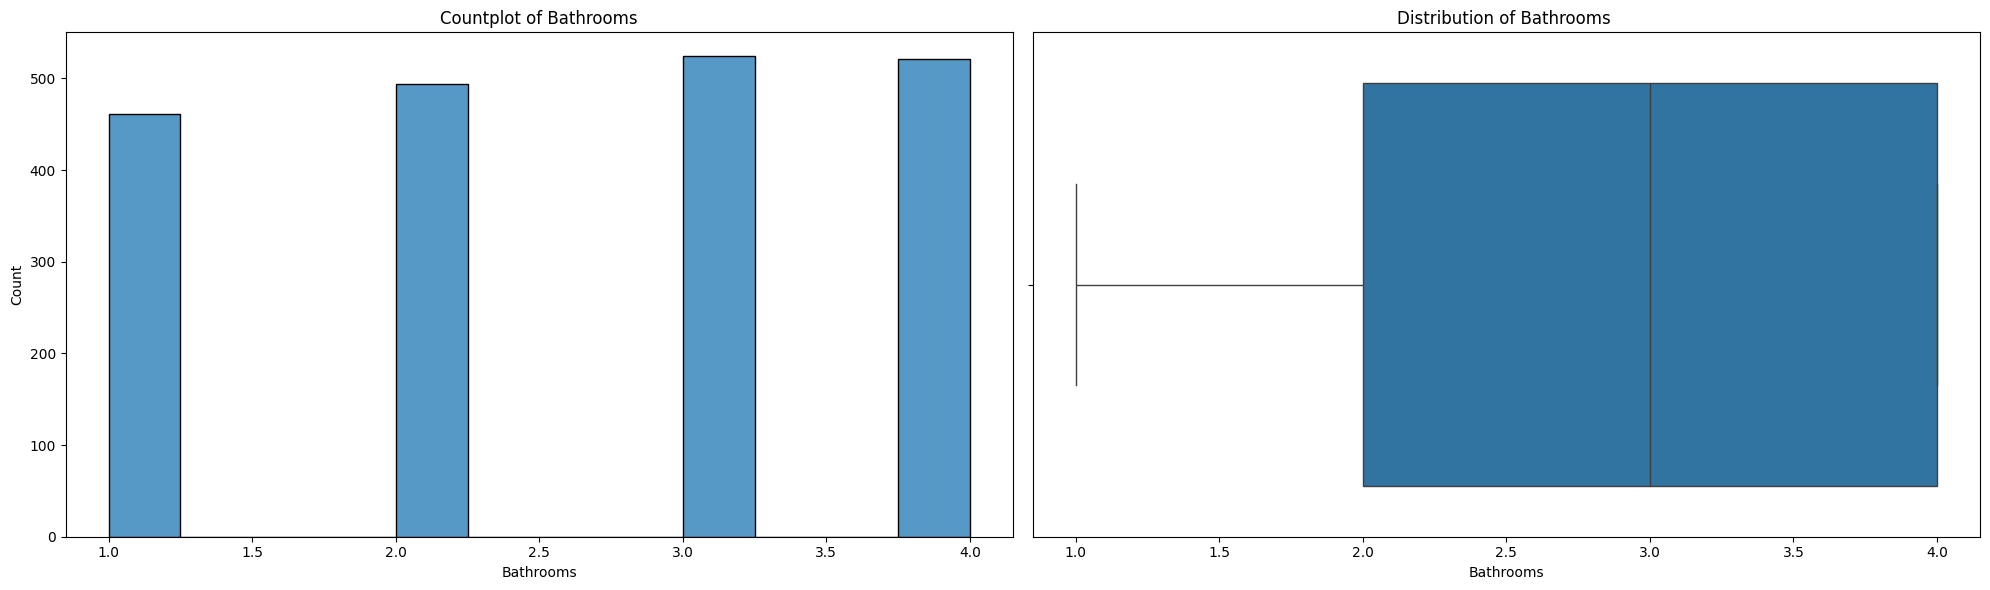

Unique vales 4
Missing values in Bathrooms 0


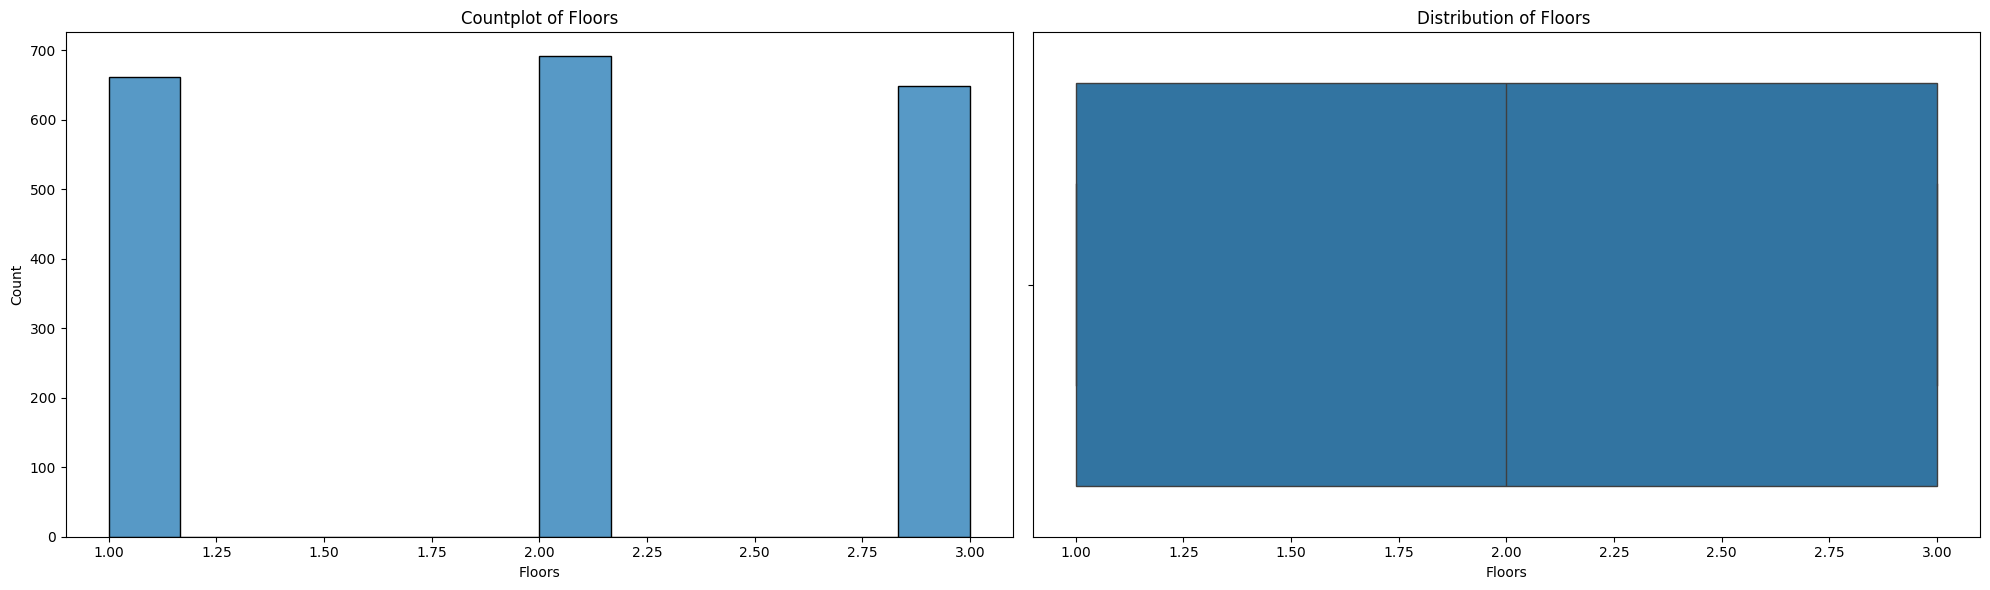

Unique vales 3
Missing values in Floors 0


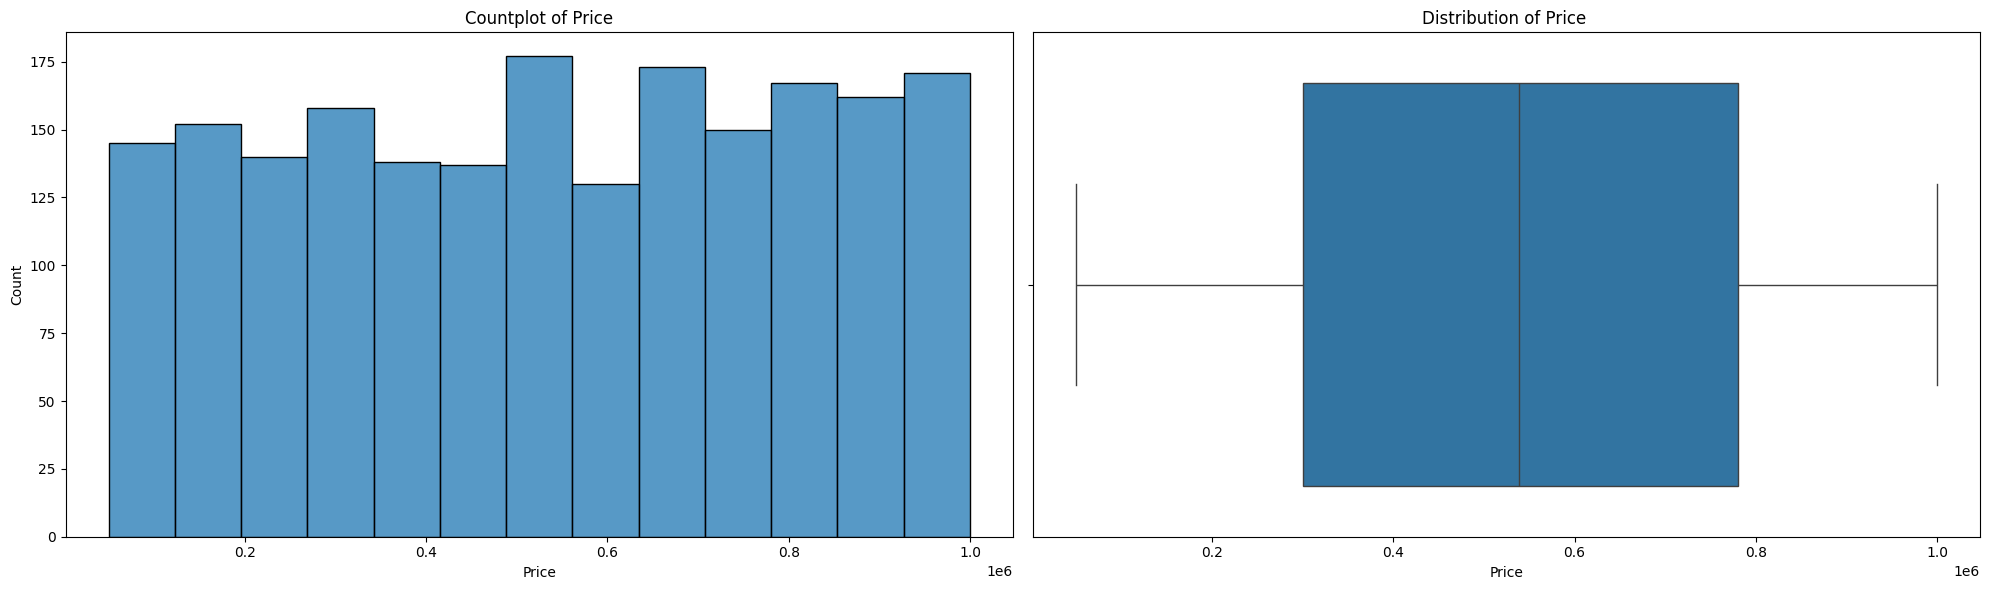

Unique vales 1999
Missing values in Price 0


In [12]:
numeric = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Price']
for col in numeric :
  plt.figure(figsize=(20,6))
  plt.subplot(1,2,1)
  sns.histplot(data = df , x = col)
  plt.title(f'Countplot of {col}')
  plt.subplot(1,2,2)
  sns.boxplot(data = df , x = col)
  plt.title(f"Distribution of {col} ")
  plt.tight_layout()
  plt.show()
  print("Unique vales" , df[col].nunique())
  print(f"Missing values in {col}" , df[col].isna().sum())

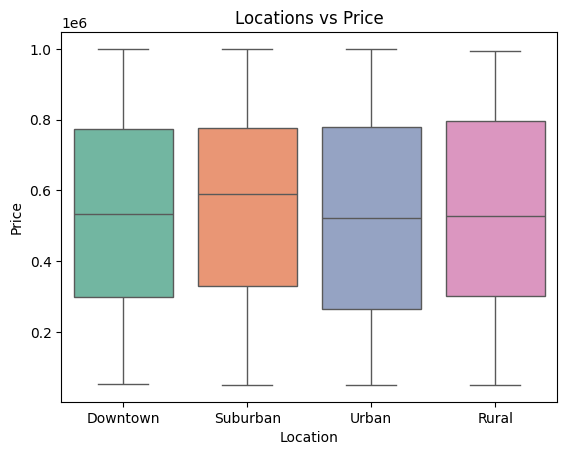

In [13]:
sns.boxplot(x=df['Location'],y=df['Price'],palette='Set2' , hue = df['Location'])
plt.title('Locations vs Price')
plt.show()

In [14]:
df['Location'].unique()

array(['Downtown', 'Suburban', 'Urban', 'Rural'], dtype=object)

In [15]:
df['Location']=df['Location'].map({'Downtown': 0, 'Suburban': 1, 'Urban': 3, 'Rural':2})

In [16]:
df['Condition'].unique()

array(['Excellent', 'Good', 'Fair', 'Poor'], dtype=object)

In [17]:
df['Condition'] = df['Condition'].map({'Excellent':3, 'Good':2, 'Fair':1, 'Poor':0})

In [18]:
df['Garage'].unique()

array(['No', 'Yes'], dtype=object)

In [19]:
df['Garage'] = df['Garage'].map({'No':0, 'Yes':1})

In [20]:
display(df)

,Area,Bedrooms,Bathrooms,Floors,Location,Condition,Garage,Price
0,1360,5,4,3,0,3,0,149919
1,4272,5,4,3,0,3,0,424998
2,3592,2,2,3,0,2,0,266746
3,966,4,2,2,1,1,1,244020
4,4926,1,4,2,0,1,1,636056
...,...,...,...,...,...,...,...,...
1995,4994,5,4,3,1,0,0,295620
1996,3046,5,2,1,1,0,1,580929
1997,1062,5,1,2,2,0,0,476925
1998,4062,3,1,2,3,3,1,161119


# ML 

In [21]:
from sklearn.model_selection import train_test_split
X = df.drop(columns = 'Price')
y = df['Price']

In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2 , random_state = 42)

In [23]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [24]:
model.fit(X_train,y_train)

LinearRegression()

In [25]:
y_pred = model.predict(X_test)

In [26]:
model.score(X_test,y_test)

-0.011466279720398598

In [27]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, y_pred)

78690891649.62787

Due to a lower score have tried to make a new pipeline and using encoding methods to train different models on the same dataset and try to verify the best model 

# Trying a different approach to solve the problem

In [28]:
df1 = pd.read_csv('/kaggle/input/datasets/zafarali27/house-price-prediction-dataset/House Price Prediction Dataset.csv')

In [29]:
df1.drop(columns=['YearBuilt' , 'Id'] , inplace = True)

In [30]:
X = df1.drop(columns = 'Price')
y = df1['Price']

In [31]:
X_train ,X_test ,y_train ,y_test = train_test_split(X ,y ,random_state  = 42 ,test_size = 0.2)

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder , RobustScaler

numeric = X.select_dtypes(include = 'int64').columns.tolist()
categoric = X.select_dtypes(include = 'object').columns.tolist()

In [33]:
numeric_encoder = make_pipeline(
    RobustScaler()
)

In [34]:
categoric_encoder = make_pipeline(
    OneHotEncoder()
)

In [35]:
preprocessor = ColumnTransformer(
    transformers = [
        ("numeric",numeric_encoder,numeric),
        ('Categoric',categoric_encoder,categoric)
    ]
)

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
Pipeline_random = Pipeline(
    steps = [
        ('Preprocess',preprocessor),
        ('Random_forest' , RandomForestRegressor(random_state=42,max_depth=5,min_samples_split=10))
    ]
)

In [37]:
Pipeline_random.fit(X_train,y_train)

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('robustscaler',
                                                                   RobustScaler())]),
                                                  ['Area', 'Bedrooms',
                                                   'Bathrooms', 'Floors']),
                                                 ('Categoric',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder())]),
                                                  ['Location', 'Condition',
                                                   'Garage'])])),
                ('Random_forest',
                 RandomForestRegressor(max_depth=5, min_samples_split=10,
                                       random_state=42))])

In [38]:
from sklearn.neighbors import KNeighborsRegressor
Pipeline_knn = Pipeline(
    steps = [
        ('Preprocess',preprocessor),
        ('KNN' , KNeighborsRegressor(n_neighbors = 5))
    ]
)

In [39]:
Pipeline_knn.fit(X_train,y_train)

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('robustscaler',
                                                                   RobustScaler())]),
                                                  ['Area', 'Bedrooms',
                                                   'Bathrooms', 'Floors']),
                                                 ('Categoric',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder())]),
                                                  ['Location', 'Condition',
                                                   'Garage'])])),
                ('KNN', KNeighborsRegressor())])

In [40]:
from sklearn.svm import SVR
Pipeline_svr = Pipeline(
    steps = [
        ('Preprocess' , preprocessor),
        ('SVR' , SVR())
    ]
)

In [41]:
Pipeline_svr.fit(X_train,y_train)

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('robustscaler',
                                                                   RobustScaler())]),
                                                  ['Area', 'Bedrooms',
                                                   'Bathrooms', 'Floors']),
                                                 ('Categoric',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder())]),
                                                  ['Location', 'Condition',
                                                   'Garage'])])),
                ('SVR', SVR())])

# Evaluations 

In [42]:
# Predict and evaluate
print("For Pipeline_random")
y_pred = Pipeline_random.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
y_pred = Pipeline_random.predict(X_test)
print("Mean Squared Error:", mse.__round__(2))
print("Mean Absolute Error:", mae.__round__(2))
print("R-squared:", r2.__round__(2))

For Pipeline_random
Mean Squared Error: 79868662334.0
Mean Absolute Error: 245359.11
R-squared: -0.03


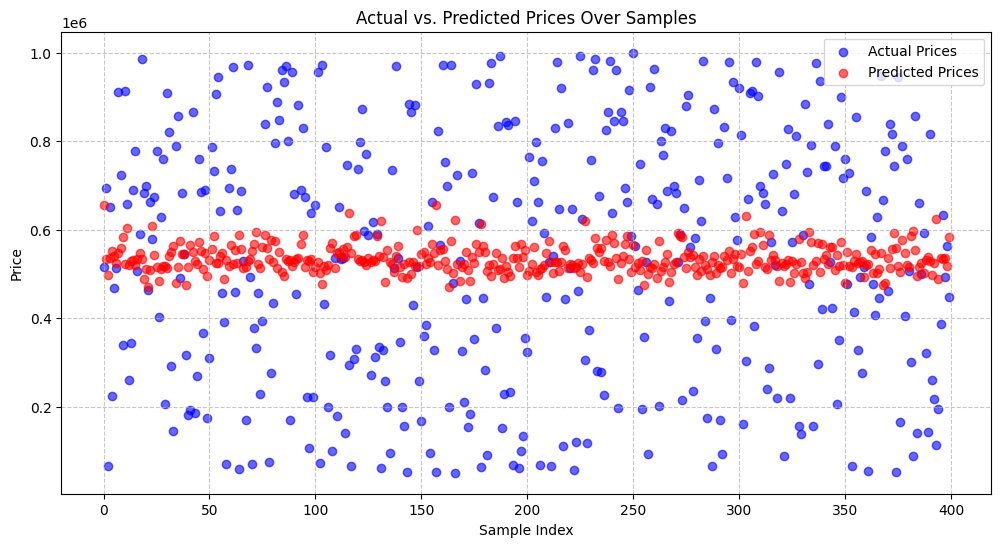

In [43]:
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual Prices', alpha=0.6)
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted Prices', alpha=0.6)
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.title('Actual vs. Predicted Prices Over Samples')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [44]:
print("For Pipeline_knn")
y_pred = Pipeline_knn.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
y_pred = Pipeline_knn.predict(X_test)
print("Mean Squared Error:", mse.__round__(2))
print("Mean Absolute Error:", mae.__round__(2))
print("R-squared:", r2.__round__(2))

For Pipeline_knn
Mean Squared Error: 98453224086.45
Mean Absolute Error: 268848.41
R-squared: -0.27


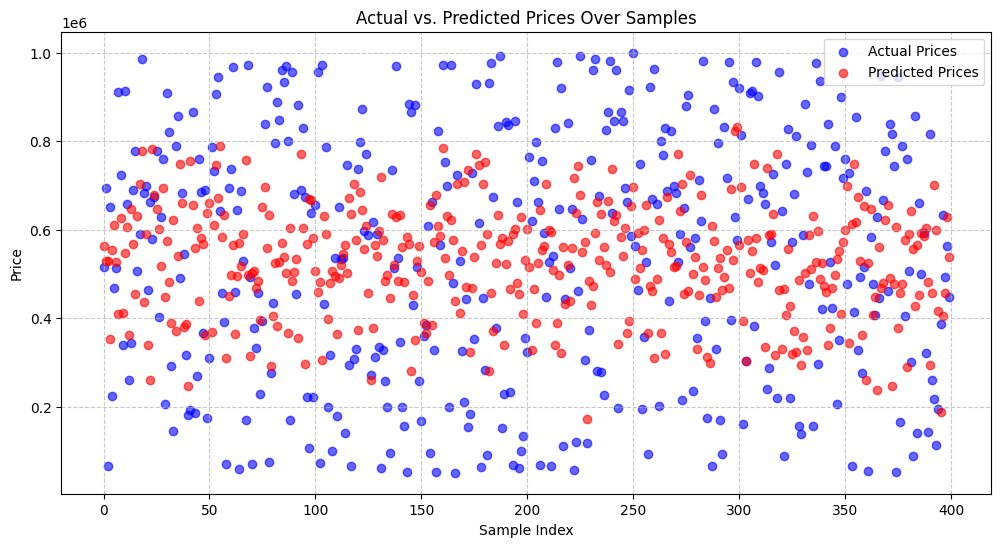

In [45]:
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual Prices', alpha=0.6)
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted Prices', alpha=0.6)
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.title('Actual vs. Predicted Prices Over Samples')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [46]:
print("For Pipeline_svr")
y_pred = Pipeline_svr.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
y_pred = Pipeline_svr.predict(X_test)
print("Mean Squared Error:", mse.__round__(2))
print("Mean Absolute Error:", mae.__round__(2))
print("R-squared:", r2.__round__(4))

For Pipeline_svr
Mean Squared Error: 77902510031.71
Mean Absolute Error: 242647.48
R-squared: -0.0013


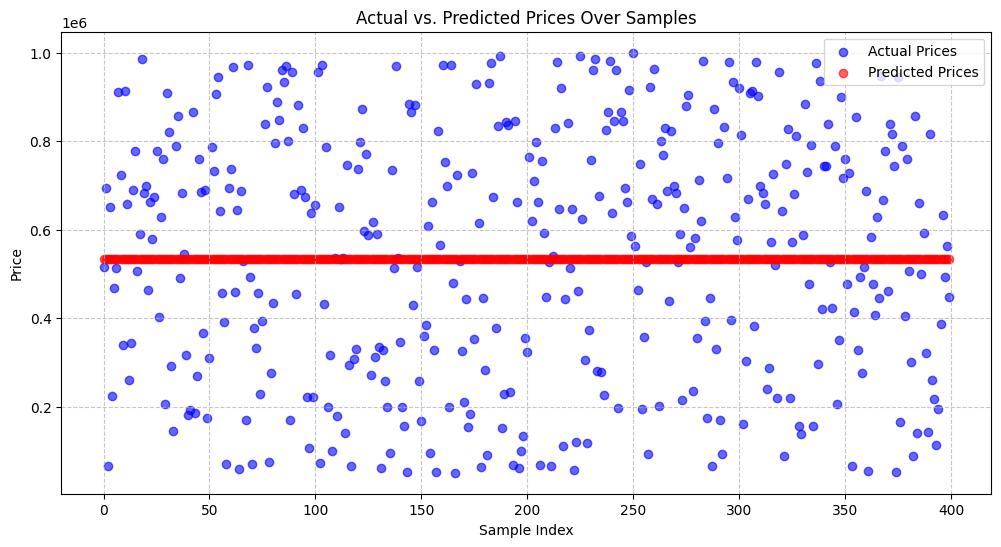

In [47]:
plt.figure(figsize=(12, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual Prices', alpha=0.6)
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Predicted Prices', alpha=0.6)
plt.xlabel('Sample Index')
plt.ylabel('Price')
plt.title('Actual vs. Predicted Prices Over Samples')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

From the above analysis it is pretty clear that the svr model performing better. Although every model is not having good score.

Thankyou for reading this notebook and if you like my work do upvote.